# How to Diagnose a Failing ChemKAN — a hands-on playbook

**This notebook teaches a method, not a result.** Notebook 09 records *what we found* about
the hydrogen failure. This one shows *how to look*, step by step, so you can run the same
reasoning on a new model, a new architecture, or a new dataset without re-deriving it.

Every step is executable. The subject is a real trained model that FAILED, and a real one
that works, so you can see the difference in every diagnostic rather than being told about it.

---

## Core principle

> **Do not diagnose from the integrated trajectory alone. Decompose the failure.**

A closed-loop trajectory is the *end* of a long chain. When it looks wrong, the wrongness
could have entered anywhere:

```
   data          Stage-1 T(t)        kinetic core       thermo pathway      closed-loop
 (is the      (is the observed    (does dY/dt make   (does dT/dt make      coupling
  target      temperature fed        sense given         sense given      (do errors
 physical?)     in correctly?)      the true state?)   the true rates?)    compound?)
      │               │                    │                  │                │
      └───────────────┴────────────────────┴──────────────────┴────────────────┘
                         each link must be tested SEPARATELY
```

Looking at the final `T(t)` plot tells you only that *something* is broken. The steps below
tell you *which link*.

## The eight questions, in order

| # | Question | Isolates |
|---|---|---|
| 0 | Is this case even supposed to ignite? | the **data** |
| 1 | Which state variable actually carries the error? | **error attribution** |
| 2 | If T is wrong, why do the species still evolve? | the **coupling** |
| 3 | Does the kinetic core work when handed the true T(t)? | **Stage-1 / open loop** |
| 4 | At an ignition state, what dT/dt does the model predict? | the **RHS itself** |
| 5 | Is it the linear branch or the KAN correction? | **inside Eq. 15** |
| 6 | Which "scaling" are we even talking about? | **four distinct scalings** |
| 7 | How do the coefficients evolve, and can the optimizer move them? | **parameters + optimizer** |

Steps 0–3 rule things *out*. Steps 4–7 localize the cause. Do them in order: step 4 is
meaningless if step 0 shows the case never ignites in the first place.

In [1]:
%matplotlib inline
# --- setup: repo-relative, read-only, no training anywhere in this notebook ---
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for p in (ROOT / "chemkan/src", ROOT / "chemkan/scripts", ROOT / "chemkan/scripts/diagnostics"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from chemkan.normalization import MinMaxNormalizer
from chemkan.dynamics import ChemKANDynamics, KineticDynamics
from chemkan.temperature import ObservedTemperature
from chemkan.solver import integrate
from chemkan.losses import chemkan_loss
from _data import load_input_scaling, load_hydrogen
from _chemistry import ELEMENT_COUNTS, ATOMIC_WEIGHTS, MOLAR_WEIGHTS
from evaluate_hydrogen import build_chemkan, solver_from_ckpt, integrate_hydrogen
from _thermo_coeffs import MECH, cantera_coefficients, resolve_training_ic
from hydrogen_thermo_intervention import ignition_delay      # THE repo ignition definition

pd.set_option("display.width", 200, "display.precision", 4)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25, "font.size": 9})

# canonical dataset + the GENUINE dense Cantera reference (never an interpolation)
npz = np.load(ROOT / "chemkan/data/generated/hydrogen.npz", allow_pickle=True)
t, ics, states = npz["t"], npz["ics"], npz["states"]
species = [str(s) for s in npz["species"]]
m = len(species)
full_norm = MinMaxNormalizer(torch.as_tensor(npz["u_min"]), torch.as_tensor(npz["u_max"]))
_dense = np.load(ROOT / "chemkan/data/generated/hydrogen_temperature_20000.npz", allow_pickle=True)
T_DENSE = np.asarray(_dense["t"], float)

def reference(T0, phi):
    """Stored 50-point Cantera trajectory (Nt, m+1) for one initial condition."""
    hit = np.where((np.abs(ics[:, 0] - T0) < 1e-9) & (np.abs(ics[:, 1] - phi) < 1e-9))[0]
    assert len(hit) == 1, f"({T0}, {phi}) is not a dataset initial condition"
    return states[int(hit[0])]

def reference_T_dense(T0, phi):
    """GENUINE 20000-point Cantera T(t). Never np.interp of the 50-point data."""
    for k_ic, k_T in (("train_ics", "train_T"), ("test_ics", "test_T")):
        ic = np.asarray(_dense[k_ic])
        hit = np.where((np.abs(ic[:, 0] - T0) < 1e-9) & (np.abs(ic[:, 1] - phi) < 1e-9))[0]
        if len(hit) == 1:
            return np.asarray(_dense[k_T])[:, int(hit[0]), 0].astype(float)
    raise AssertionError(f"({T0}, {phi}) not in the dense cache")

def load_model(run_dir):
    """Rebuild a trained ChemKAN from a run directory. Read-only."""
    ck = torch.load(Path(run_dir) / "checkpoint_final.pt", map_location="cpu",
                    weights_only=False)
    mdl = build_chemkan(ck, m, "cpu")
    return dict(ckpt=ck, model=mdl, solver=solver_from_ckpt(ck),
                input_norm=load_input_scaling(ck, "cpu"), run_dir=Path(run_dir))

def closed_loop(M, T0, phi, tt=None):
    """Integrate from the initial condition ALONE -> (Nt, m+1). This is the real test."""
    tt = t if tt is None else tt
    u0 = torch.as_tensor(reference(T0, phi)[0], dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        return integrate_hydrogen(M["model"], M["input_norm"], M["solver"], u0,
                                  torch.as_tensor(tt, dtype=torch.float32))[:, 0].numpy()

def normstate(a):
    """Eq. 18 coordinates: train-only min-max, so every state is comparable."""
    return full_norm.normalize(torch.as_tensor(np.asarray(a), dtype=torch.float32)).numpy()

DIAG = ROOT / "results/reproduction/chemkan/hydrogen/diagnostics"
print("ready |", m, "species:", species)

ready | 9 species: ['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'N2']


## The two models: FAILED vs CONTROL

Diagnosis is comparative. A diagnostic that "looks bad" is only informative if you know what
it looks like when things are **fine**. So we load two models trained from the *same*
Stage-1 checkpoint, differing only in how the nine Eq. 14 thermodynamic coefficients were
initialized:

* **FAILED** — `thermo_init_random_stage2_10000_seed0` (default init). Does not ignite.
* **CONTROL** — `thermo_init_cantera_stage2_10000_seed0` (physically-scaled init). Ignites.

Always carry a control through your diagnostics. Half of these plots are uninterpretable
alone.

In [2]:
FAILED = load_model(DIAG / "thermo_init_random_stage2_10000_seed0")
CONTROL = load_model(DIAG / "thermo_init_cantera_stage2_10000_seed0")

# --- the dataset: 35 TRAINING conditions + 1 held-out -------------------------------
is_test = np.asarray(npz["is_test"], bool)
TRAIN_ICS = [(float(a), float(b)) for a, b in ics[~is_test]]
TEST_ICS  = [(float(a), float(b)) for a, b in ics[is_test]]
print(f"the model was TRAINED on {len(TRAIN_ICS)} conditions; {len(TEST_ICS)} held out")
print(f"held-out condition: {TEST_ICS}")

# Two conditions are singled out ONLY for plotting, because they are the ones the paper
# shows in Fig. 7. They are NOT the training set -- every split-level metric below is
# computed over all 35 training conditions. Change these to inspect any other case.
TRAIN_C = (1050.0, 0.9, "training")     # a representative TRAINING condition (Fig. 7 left)
HELD_C  = (1150.0, 1.3, "held-out")     # THE held-out condition            (Fig. 7 right)
CONDS = [TRAIN_C, HELD_C]
assert (TRAIN_C[0], TRAIN_C[1]) in TRAIN_ICS and (HELD_C[0], HELD_C[1]) in TEST_ICS

for name, M in (("FAILED  (random init)", FAILED), ("CONTROL (Cantera init)", CONTROL)):
    n = sum(p.numel() for p in M["model"].parameters())
    print(f"{name:26s} params={n}  arch={M['ckpt']['architecture']}")

the model was TRAINED on 35 conditions; 1 held out
held-out condition: [(1150.0, 1.3)]
FAILED  (random init)      params=344  arch={'hidden_dim': 3, 'num_basis': 5, 'n_mu': 3, 'use_base_act': False}
CONTROL (Cantera init)     params=344  arch={'hidden_dim': 3, 'num_basis': 5, 'n_mu': 3, 'use_base_act': False}


### Why only two conditions are plotted — and why that is not the whole evaluation

`TRAIN_C` and `HELD_C` are **plotting choices**, not the training set. The model was fitted
to **35** training conditions and evaluated on **1** held-out condition. Two are singled out
because they are the cases the paper displays in Fig. 7, which makes visual comparison
possible.

A diagnosis based on two trajectories alone would be fragile: a model can behave well at one
condition and badly elsewhere. So before using them, confirm they are *representative* by
computing the error over the **entire** split.

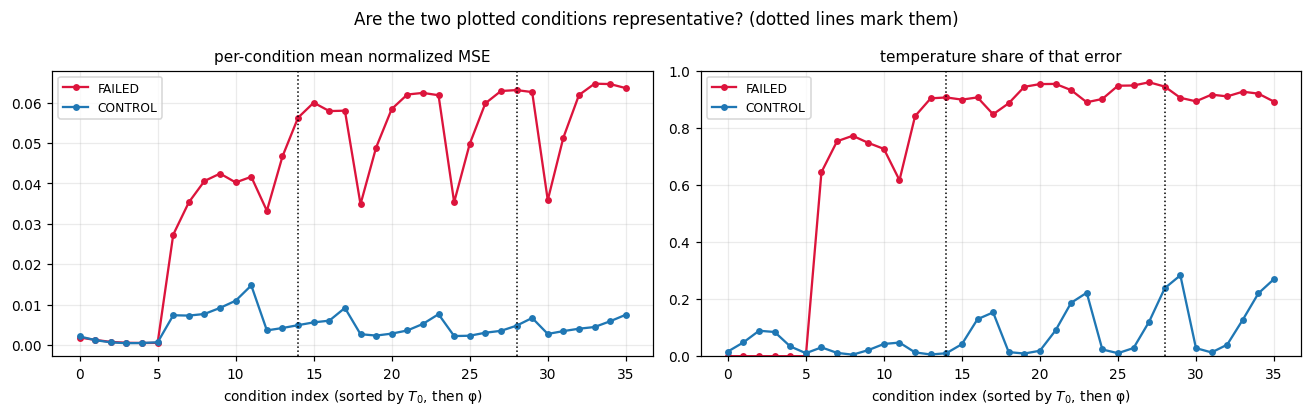

case_MSE           T_MSE         T_share        
                     mean     max    mean     max    mean     max
model   split                                                    
CONTROL held-out   0.0048  0.0048  0.0113  0.0113  0.2382  0.2382
        train      0.0047  0.0147  0.0041  0.0202  0.0716  0.2833
FAILED  held-out   0.0631  0.0631  0.5960  0.5960  0.9444  0.9444
        train      0.0425  0.0647  0.3737  0.6034  0.7211  0.9595

  FAILED: plotted training condition case_MSE = 0.0563 -> 57th percentile of the 35 (IQR 0.0351-0.0609)  INSIDE the IQR
 CONTROL: plotted training condition case_MSE = 0.0049 -> 57th percentile of the 35 (IQR 0.0025-0.0070)  INSIDE the IQR

If a plotted condition sat at an extreme percentile it would be a poor representative,
and conclusions drawn from it would need re-checking on the full split.


In [3]:
# Per-condition closed-loop error across ALL 35 training conditions + the held-out one.
rows = []
for (T0, phi) in TRAIN_ICS + TEST_ICS:
    ref = reference(T0, phi)
    for name, M in (("FAILED", FAILED), ("CONTROL", CONTROL)):
        per = ((normstate(closed_loop(M, T0, phi)) - normstate(ref)) ** 2).mean(axis=0)
        rows.append(dict(model=name, T0=T0, phi=phi,
                         split="held-out" if (T0, phi) in TEST_ICS else "train",
                         case_MSE=per.mean(), T_MSE=per[-1],
                         T_share=per[-1] / per.sum()))
allc = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for a, (col, ttl) in zip(ax, [("case_MSE", "per-condition mean normalized MSE"),
                              ("T_share", "temperature share of that error")]):
    for name, c in (("FAILED", "crimson"), ("CONTROL", "#1f77b4")):
        g = allc[allc.model == name].sort_values(["T0", "phi"])
        a.plot(range(len(g)), g[col].values, "o-", ms=3.5, color=c, label=name)
    for k, (T0, phi) in enumerate(sorted(TRAIN_ICS + TEST_ICS)):
        if (T0, phi) in [(TRAIN_C[0], TRAIN_C[1]), (HELD_C[0], HELD_C[1])]:
            a.axvline(k, color="k", ls=":", lw=1)
    a.set_xlabel("condition index (sorted by $T_0$, then φ)"); a.set_title(ttl, fontsize=10)
    a.legend(fontsize=8)
ax[1].set_ylim(0, 1)
fig.suptitle("Are the two plotted conditions representative? "
             "(dotted lines mark them)", fontsize=11)
fig.tight_layout(); plt.show()

summary = allc.groupby(["model", "split"])[["case_MSE", "T_MSE", "T_share"]].agg(["mean", "max"])
display(summary.round(4))

# Verify, rather than assert, that the plotted training condition is representative:
# where does it fall within the distribution over all 35 training conditions?
for name in ("FAILED", "CONTROL"):
    tr = allc[(allc.model == name) & (allc.split == "train")]
    v = float(tr[(tr.T0 == TRAIN_C[0]) & (tr.phi == TRAIN_C[1])].case_MSE.iloc[0])
    pct = 100.0 * (tr.case_MSE < v).mean()
    q1, q3 = tr.case_MSE.quantile([.25, .75])
    print(f"{name:>8}: plotted training condition case_MSE = {v:.4f} -> {pct:.0f}th percentile "
          f"of the 35 (IQR {q1:.4f}-{q3:.4f})  {'INSIDE the IQR' if q1 <= v <= q3 else 'OUTSIDE the IQR'}")
print("\nIf a plotted condition sat at an extreme percentile it would be a poor representative,")
print("and conclusions drawn from it would need re-checking on the full split.")

---
# Step 0 — Is this case even supposed to ignite? Look at the trajectories.

**Before** you call a flat trajectory a bug, look at what the *reference* chemistry actually
does across the grid. Some initial conditions genuinely do **not** ignite inside the 0.6 ms
window — the paper says so explicitly: *"the lowest temperature cases did not see ignition
given the time span of 0.6 ms"* (30 of 36 cases ignited).

Skip this step and considerable effort can be spent debugging a model that is correctly
predicting a non-event.

**Plot `T(t)`, do not reduce it to a number.** A scalar like "total rise" cannot tell you
*how* the temperature got there, and that shape is the whole point:

* **no ignition** — a slow creep of a few kelvin, never leaving the initial value;
* **late/marginal ignition** — a long flat induction period, then a rise near the end of the
  window (or cut off by it);
* **clean ignition** — flat induction, then a near-vertical rise, then a plateau.

These three look identical in a "rise > 100 K" boolean. They are completely different
physics, and your model has to reproduce the *shape*, not the flag.

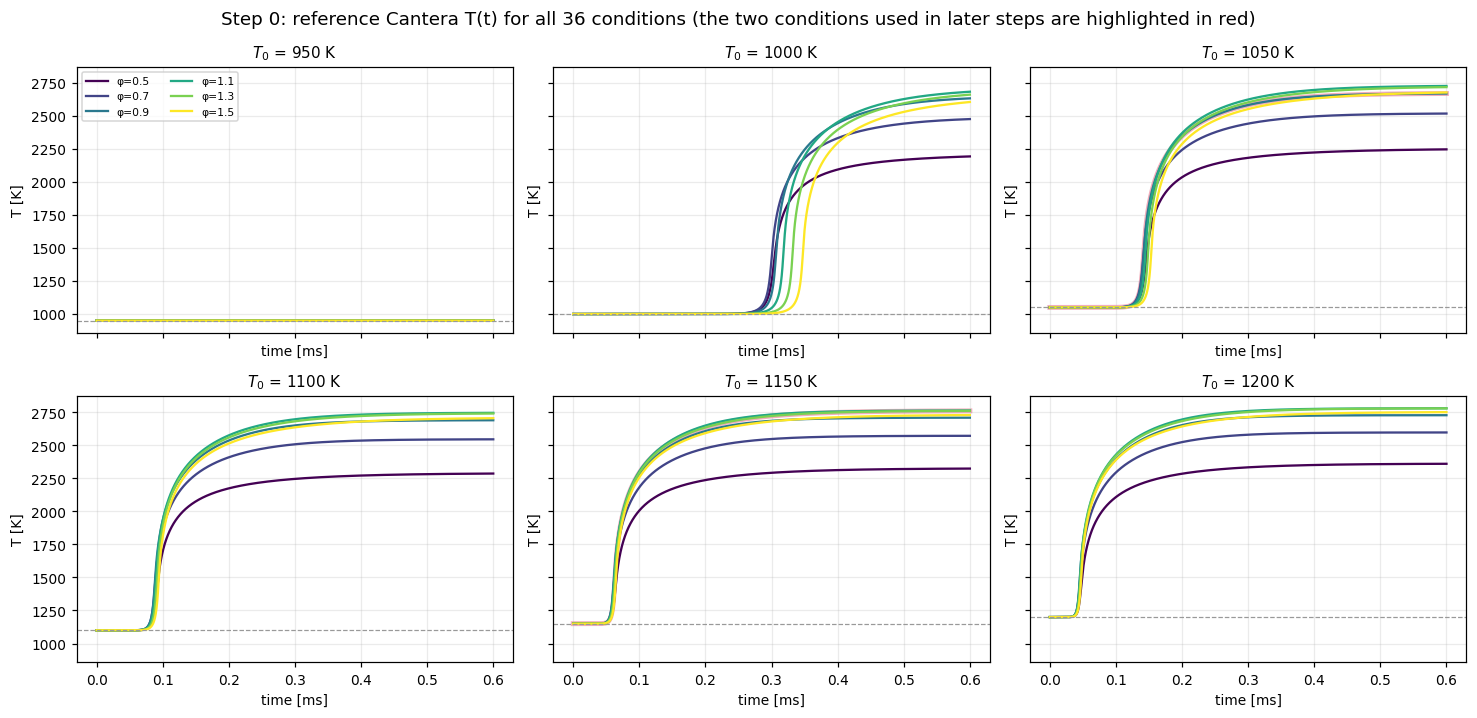

In [4]:
# Every reference trajectory in the dataset, grouped by initial temperature.
T0s = sorted(set(ics[:, 0])); phis = sorted(set(ics[:, 1]))
cmap = plt.get_cmap("viridis")
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.6), sharex=True, sharey=True)
for ax, T0 in zip(axes.ravel(), T0s):
    for j, phi in enumerate(phis):
        Td = reference_T_dense(T0, phi)
        ax.plot(T_DENSE * 1e3, Td, lw=1.5, color=cmap(j / (len(phis) - 1)),
                label=f"φ={phi:g}")
        if (T0, phi) in [(c[0], c[1]) for c in CONDS]:        # mark the two we will use
            ax.plot(T_DENSE * 1e3, Td, lw=3.2, color="crimson", alpha=.35, zorder=0)
    ax.axhline(T0, color="#999", lw=.8, ls="--")
    ax.set_title(f"$T_0$ = {T0:.0f} K", fontsize=10)
    ax.set_xlabel("time [ms]"); ax.set_ylabel("T [K]")
axes[0, 0].legend(fontsize=7, ncol=2, loc="upper left")
fig.suptitle("Step 0: reference Cantera T(t) for all 36 conditions "
             "(the two conditions used in later steps are highlighted in red)", fontsize=12)
fig.tight_layout(); plt.show()

**How to read it.** Read the panels left to right, top to bottom:

* **950 K** — the curves barely leave the dashed initial line. Nothing ignites in the window.
  A model that outputs a flat trajectory here is **right**, not broken.
* **1000 K** — the interesting row. Some φ ignite late, some are still climbing when the
  window ends. These are the *marginal* cases, and they are where a surrogate is most likely
  to be judged unfairly by a threshold.
* **1050 K and above** — clean ignition: a flat induction period, a sharp rise, a plateau.
  The induction period shortens as `T₀` rises, which is the trend a good model must capture.

Notice also that φ orders the curves systematically — richer mixtures ignite sooner and
plateau differently — so a model can get the *peak* right while getting the φ-ordering wrong.

Now quantify what the curves show, keeping the shape information rather than replacing it:

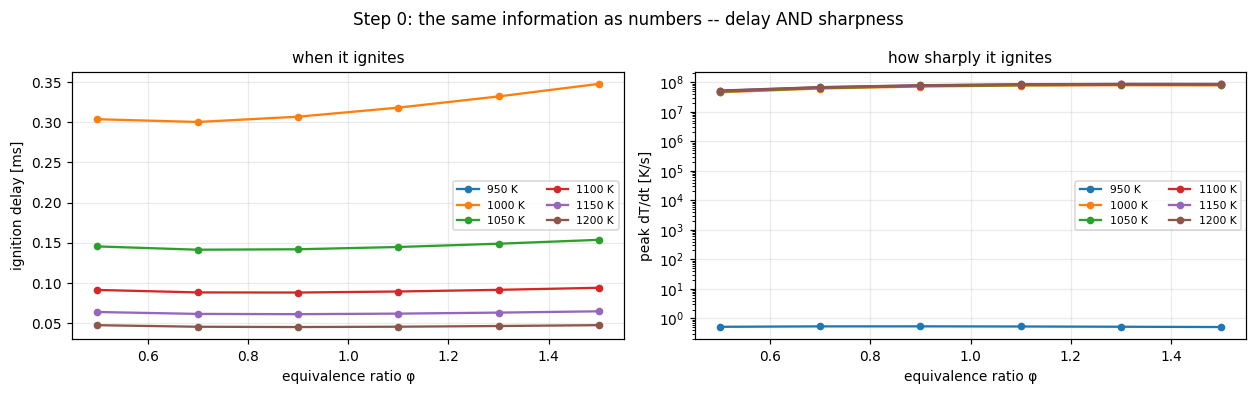

30 of 36 conditions ignite within 0.6 ms
conditions with NO ignition (a flat prediction there is CORRECT):
   T0  phi  rise_K
950.0  0.5  0.0002
950.0  0.7  0.0002
950.0  0.9  0.0002
950.0  1.1  0.0002
950.0  1.3  0.0002
950.0  1.5  0.0002


,T0,phi,rise_K,t_first_plus100K_ms,ignition_delay_ms,max_dTdt_K_per_s,reaches_plateau
6,1000.0,0.5,1193.358,0.293,0.304,4.5232e+07,True
7,1000.0,0.7,1476.112,0.290,0.300,6.0924e+07,True
8,1000.0,0.9,1633.077,0.297,0.307,7.1102e+07,True
9,1000.0,1.1,1683.189,0.308,0.318,7.6629e+07,True
10,1000.0,1.3,1661.077,0.322,0.332,7.8526e+07,True
11,1000.0,1.5,1605.442,0.337,0.348,7.7756e+07,True
12,1050.0,0.5,1196.862,0.138,0.145,4.7458e+07,True
13,1050.0,0.7,1467.907,0.134,0.141,6.3242e+07,True
14,1050.0,0.9,1619.718,0.135,0.142,7.3550e+07,True
15,1050.0,1.1,1676.884,0.138,0.145,7.9238e+07,True


In [5]:
# Numbers that DESCRIBE the curves above -- induction, sharpness, delay -- not a bare flag.
rows = []
for T0 in T0s:
    for phi in phis:
        Td = reference_T_dense(T0, phi)
        dly = ignition_delay(T_DENSE, Td)                  # repo definition: argmax dT/dt
        above = np.flatnonzero(Td >= T0 + 100.0)
        rows.append(dict(
            T0=T0, phi=phi,
            rise_K=Td.max() - Td[0],
            t_first_plus100K_ms=np.nan if above.size == 0 else T_DENSE[above[0]] * 1e3,
            ignition_delay_ms=np.nan if dly is None else dly * 1e3,
            max_dTdt_K_per_s=np.gradient(Td, T_DENSE).max(),
            reaches_plateau=bool(Td[-1] > 0.95 * Td.max())))
grid = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
for T0 in T0s:
    g = grid[grid.T0 == T0]
    ax[0].plot(g.phi, g.ignition_delay_ms, "o-", ms=4, label=f"{T0:.0f} K")
    ax[1].semilogy(g.phi, g.max_dTdt_K_per_s, "o-", ms=4, label=f"{T0:.0f} K")
ax[0].set_ylabel("ignition delay [ms]"); ax[0].set_title("when it ignites", fontsize=10)
ax[1].set_ylabel("peak dT/dt [K/s]"); ax[1].set_title("how sharply it ignites", fontsize=10)
for a in ax:
    a.set_xlabel("equivalence ratio φ"); a.legend(fontsize=7, ncol=2)
fig.suptitle("Step 0: the same information as numbers -- delay AND sharpness", fontsize=11)
fig.tight_layout(); plt.show()

no_ign = grid[grid.ignition_delay_ms.isna()]
print(f"{len(grid) - len(no_ign)} of {len(grid)} conditions ignite within {t[-1]*1e3:.1f} ms")
print("conditions with NO ignition (a flat prediction there is CORRECT):")
print(no_ign[["T0", "phi", "rise_K"]].to_string(index=False))
display(grid[grid.T0.isin([1000.0, 1050.0])].round(3))

> **About the 100 K threshold.** `ignition_delay` returns the time of maximum `dT/dt`, but only
> if the total rise exceeds 100 K. That guard is **ours, not the paper's** — it exists because
> a perfectly flat trajectory still has a mathematical `argmax` of its derivative, so without
> it a failed model would report a confident, meaningless "ignition delay" wherever numerical
> noise happened to peak. It decides whether the delay is *meaningful*; it is **not** a
> physical definition of ignition, and it is not a substitute for looking at the curve.

Our two representative conditions (1050 K/φ 0.9 and 1150 K/φ 1.3) both sit firmly in the
clean-ignition regime, with sharp rises and well-defined delays. So a flat prediction there
*is* a real failure, and we may proceed.

---
# Step 1 — Which state variable actually carries the error?

Now integrate from the initial condition alone (**closed loop** — the model supplies its own
temperature and its own species) and ask *where* the error lives.

**Do not eyeball the trajectory.** Put every state in the same Eq. 18 normalized coordinates
and compare like with like. Species mass fractions are O(0.01–0.2); temperature is O(10³) K.
In raw units temperature will always "look" like the biggest error. Normalized, the
comparison is meaningful.

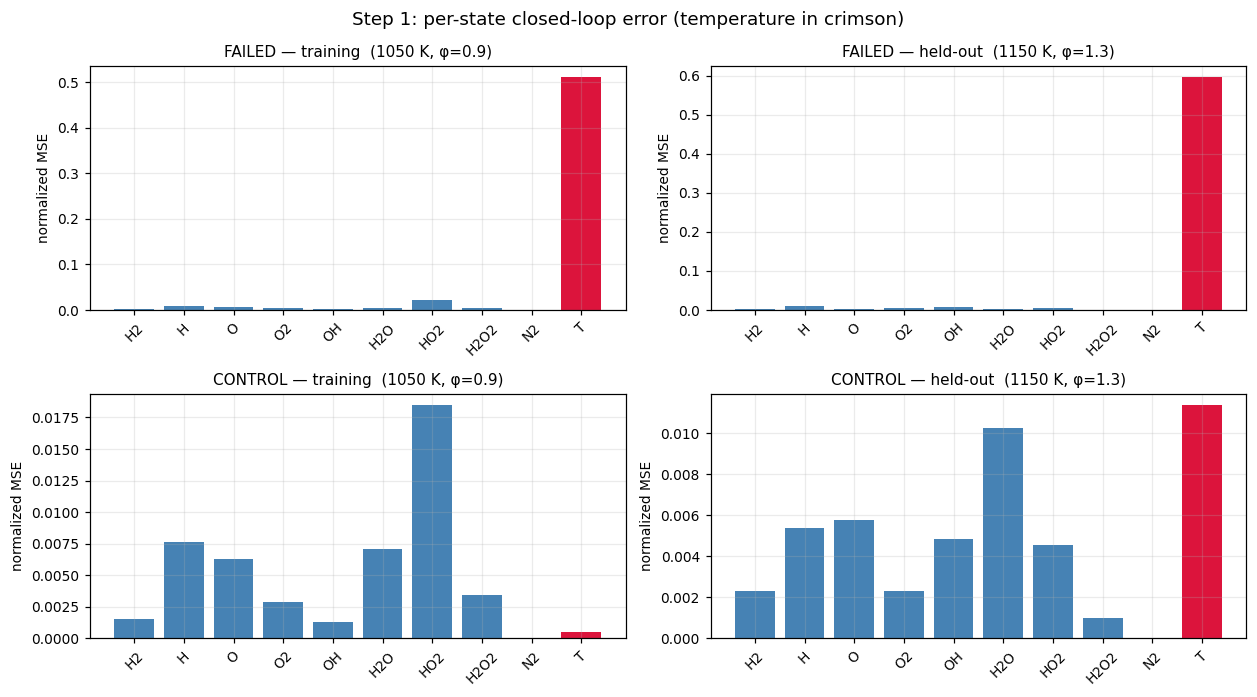

,,T,H2,O2,H2O,T share of total
FAILED,training,0.5102,0.0012,0.0046,0.0032,90.6%
CONTROL,training,0.0005,0.0015,0.0028,0.0071,1.0%
FAILED,held-out,0.5960,0.0017,0.0038,0.0031,94.4%
CONTROL,held-out,0.0113,0.0023,0.0023,0.0102,23.8%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.4))
per_state = {}
for c, (T0, phi, role) in enumerate(CONDS):
    ref = reference(T0, phi)
    for r, (name, M) in enumerate((("FAILED", FAILED), ("CONTROL", CONTROL))):
        pred = closed_loop(M, T0, phi)
        per = ((normstate(pred) - normstate(ref)) ** 2).mean(axis=0)   # per-state, normalized
        per_state[(name, role)] = per
        ax = axes[r, c]
        ax.bar(species + ["T"], per, color=["crimson" if s == "T" else "steelblue"
                                            for s in species + ["T"]])
        ax.set_title(f"{name} — {role}  ({T0:.0f} K, φ={phi})", fontsize=10)
        ax.set_ylabel("normalized MSE"); ax.tick_params(axis="x", rotation=45)
fig.suptitle("Step 1: per-state closed-loop error (temperature in crimson)", fontsize=12)
fig.tight_layout(); plt.show()

tbl = pd.DataFrame(per_state).T
tbl.columns = species + ["T"]
tbl["T share of total"] = (tbl["T"] / tbl.sum(axis=1)).map("{:.1%}".format)
display(tbl[["T", "H2", "O2", "H2O", "T share of total"]])

**How to read it.** In the FAILED model, temperature carries the overwhelming majority of the
normalized error. In the CONTROL it does not. That is the signal that sends you down the
thermodynamic branch rather than the kinetic one.

> **Common misinterpretation — a statement to avoid:** *"the species work, the temperature doesn't."*
> This step does **not** license that claim. It says temperature *dominates the error*. It
> says nothing about whether the species are quantitatively correct — and Step 2 shows why
> that distinction matters enormously.

---
# Step 2 — If the temperature is wrong, why do the species still evolve?

This is one of the most informative questions to ask about a failed combustion surrogate, and
it is easily overlooked.

Stage 2 is a **feedback loop**:

$$(Y, T)\;\longrightarrow\;\frac{dY}{dt}\;\longrightarrow\;\frac{dT}{dt}\;\longrightarrow\;(Y', T')\;\longrightarrow\cdots$$

Arrhenius kinetics depend on temperature *exponentially*. If the model sits at ~1050 K while
the real reactor climbs toward ~2700 K, then the species rates are being evaluated at
**dramatically wrong temperatures**. Two consequences follow:

1. Species that still reach roughly the right final composition are doing so *for the wrong
   reason* — the model evaluates them at temperatures far from the true ones.
   (Careful: this does **not** mean isothermal reaction is impossible — see the caution below.)
2. Therefore a model can look like it "gets the chemistry right" and still be deeply broken.

**What to look at:** reaction extent (how far each species travelled toward its reference
final value) side by side with the temperature rise.

In [7]:
rows = []
for T0, phi, role in CONDS:
    ref = reference(T0, phi)
    pred = closed_loop(FAILED, T0, phi)
    for sp in ("H2", "O2", "H2O"):
        k = species.index(sp)
        d_ref = ref[-1, k] - ref[0, k]
        d_mod = pred[-1, k] - pred[0, k]
        rows.append(dict(condition=role, species=sp,
                         reaction_extent_pct=100 * d_mod / d_ref if d_ref else np.nan))
    rows.append(dict(condition=role, species="T (rise K)",
                     reaction_extent_pct=100 * (pred[:, -1].max() - pred[0, -1])
                                          / (ref[:, -1].max() - ref[0, -1])))
extent = pd.DataFrame(rows).pivot(index="condition", columns="species",
                                  values="reaction_extent_pct").round(1)
print("FAILED model: how far did each quantity travel, as % of the reference change?\n")
display(extent)
print("Species reach ~100% of their reference change while temperature reaches ~0.5%.")
print("The chemistry ran essentially to completion while T stayed flat.")
print("CAUTION: that alone is NOT proof of broken kinetics -- see the note below.")

FAILED model: how far did each quantity travel, as % of the reference change?



species,H2,H2O,O2,T (rise K)
condition,,,,
held-out,99.7,101.3,103.2,0.6
training,97.8,95.4,94.5,0.5


Species reach ~100% of their reference change while temperature reaches ~0.5%.
The chemistry ran essentially to completion while T stayed flat.
CAUTION: that alone is NOT proof of broken kinetics -- see the note below.


**How to read it.** Species reach ~95–103 % of their reference change while temperature
reaches well under 1 %. The model burned its fuel and released no heat.

> **Caution — a tempting but WRONG inference.** It is natural to call this "impossible",
> reasoning that Arrhenius chemistry at a frozen 1050 K should barely react. **That is false
> for this system.** Cantera with the energy equation disabled at a fixed 1050 K reaches
> `max|ΔY| = 0.210` over the same 0.6 ms — essentially the adiabatic extent (0.201).
> H2/air at 1050 K and 1 atm burns out inside the window *without* any temperature rise.
> Full reaction at flat temperature is therefore **not** by itself evidence of broken kinetics.
>
> What is defensible: (a) the **thermodynamic pathway** fails to convert the reaction into
> heat, and (b) the species are evaluated at temperatures far from the true ones, so
> agreement in final composition does not imply a correct kinetic model. To test the
> kinetics properly, compare against an **isothermal reference at that fixed temperature** —
> see Notebook 09 §6D, where the real defect appears at **950 K** (the learned core reacts
> ~10^5x more than the truth), not at 1050 K.

> **Common misinterpretation — the choice of plotted species matters.** H2/O2/H2O are the visually dominant curves
> and the most forgiving. The radicals (H, O, OH) and especially the short-lived
> intermediates (HO2, H2O2) are chemically decisive for ignition and much harder to get
> right. Never conclude "Stage 1 is fine" from a plot of the three big species.

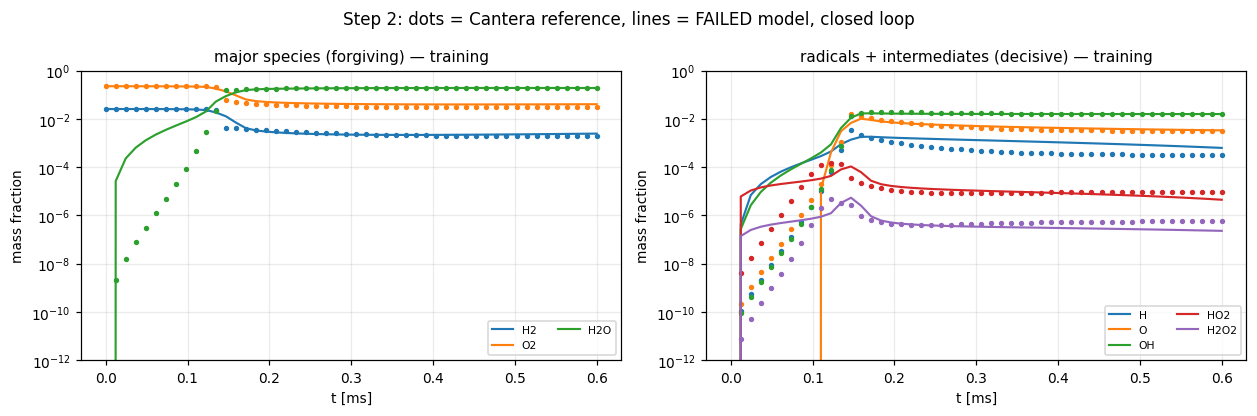

In [8]:
# The same trajectory, radicals included. Note the log axis -- these live 3-6 decades below
# the major species and are invisible on a linear plot.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
T0, phi, role = TRAIN_C
ref, pred = reference(T0, phi), closed_loop(FAILED, T0, phi)
for ax, group, title in ((axes[0], ["H2", "O2", "H2O"], "major species (forgiving)"),
                         (axes[1], ["H", "O", "OH", "HO2", "H2O2"], "radicals + intermediates (decisive)")):
    for sp in group:
        k = species.index(sp)
        line, = ax.plot(t * 1e3, pred[:, k], "-", lw=1.4, label=sp)
        ax.plot(t * 1e3, ref[:, k], "o", ms=2.5, color=line.get_color())
    ax.set_yscale("log"); ax.set_ylim(1e-12, 1)
    ax.set_title(f"{title} — {role}", fontsize=10)
    ax.set_xlabel("t [ms]"); ax.set_ylabel("mass fraction"); ax.legend(fontsize=7, ncol=2)
fig.suptitle("Step 2: dots = Cantera reference, lines = FAILED model, closed loop", fontsize=11)
fig.tight_layout(); plt.show()

---
# Step 3 — Open the loop: does the kinetic core work when handed the true T(t)?

The closed loop confounds everything. To test the kinetic core *alone*, remove the feedback:
integrate the **species only**, with the true temperature history supplied externally from
the data. This is exactly the Stage-1 regime the paper describes.

If the kinetic core produces sensible species dynamics here, the core is **not inert** —
which rules out "the network learned nothing" and points you downstream to the thermodynamic
pathway.

**Also check the temperature provider itself.** Stage 1 depends on `T(t)` being fed in
correctly; a broken interpolation would masquerade as a broken model. Cheap to verify, so
verify it.

In [9]:
# 3a. Is the externally supplied temperature actually correct?
i_tr = np.where((np.abs(_dense["train_ics"][:, 0] - 1050.0) < 1e-9)
                & (np.abs(_dense["train_ics"][:, 1] - 0.9) < 1e-9))[0][0]
T_provider = np.asarray(_dense["train_T"])[:, i_tr, 0]
j = np.searchsorted(T_DENSE, t)
err = np.abs(T_provider[np.clip(j, 0, len(T_DENSE) - 1)] - reference(1050.0, 0.9)[:, -1])
print(f"dense provider vs dataset at the shared instants: max |ΔT| = {err.max():.3e} K")
print(f"provider resolution: {len(T_DENSE)} points, {np.diff(T_DENSE).mean()*1e9:.0f} ns spacing")
print("-> the temperature provider is NOT the problem; move on." if err.max() < 1.0
      else "-> PROVIDER MISMATCH: stop and fix this first.")

dense provider vs dataset at the shared instants: max |ΔT| = 3.173e-01 K
provider resolution: 20000 points, 30 ns spacing
-> the temperature provider is NOT the problem; move on.


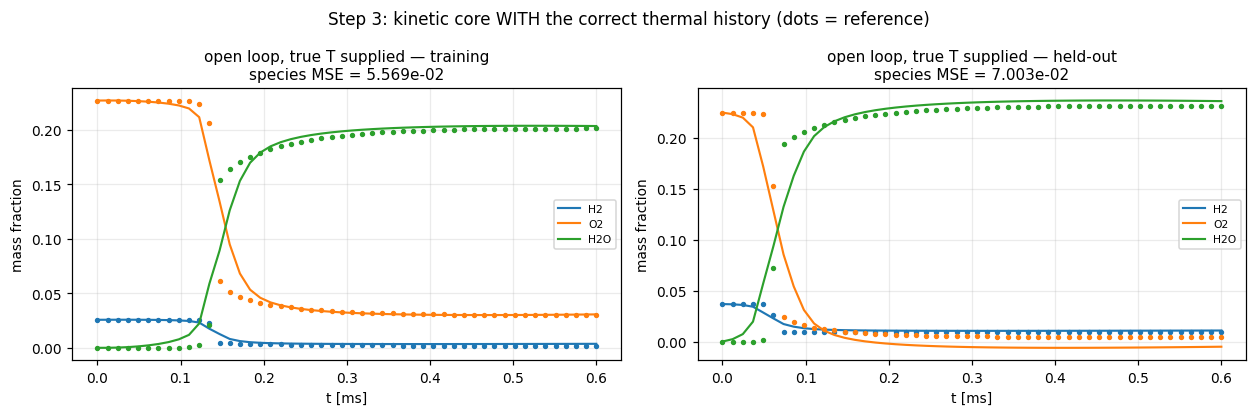

In [10]:
# 3b. Kinetic core with the TRUE temperature supplied (Stage-1 regime, open loop).
def stage1_open_loop(M, T0, phi):
    ref = reference(T0, phi)
    obsT = ObservedTemperature(torch.as_tensor(t, dtype=torch.float32),
                               torch.as_tensor(ref[:, -1], dtype=torch.float32).reshape(-1, 1, 1))
    kin = KineticDynamics(M["model"].kinetic, obsT, input_normalizer=M["input_norm"])
    with torch.no_grad():
        return integrate(kin, torch.as_tensor(ref[0, :m], dtype=torch.float32).unsqueeze(0),
                         torch.as_tensor(t, dtype=torch.float32), M["solver"])[:, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for ax, (T0, phi, role) in zip(axes, CONDS):
    ref = reference(T0, phi)
    s1 = stage1_open_loop(FAILED, T0, phi)
    mse = float(((normstate(np.c_[s1, ref[:, -1]])[:, :m] - normstate(ref)[:, :m]) ** 2).mean())
    for sp in ("H2", "O2", "H2O"):
        k = species.index(sp)
        line, = ax.plot(t * 1e3, s1[:, k], "-", lw=1.4, label=sp)
        ax.plot(t * 1e3, ref[:, k], "o", ms=2.5, color=line.get_color())
    ax.set_title(f"open loop, true T supplied — {role}\nspecies MSE = {mse:.3e}", fontsize=10)
    ax.set_xlabel("t [ms]"); ax.set_ylabel("mass fraction"); ax.legend(fontsize=7)
fig.suptitle("Step 3: kinetic core WITH the correct thermal history (dots = reference)",
             fontsize=11)
fig.tight_layout(); plt.show()

**How to read it.** With the correct thermal history supplied, the kinetic core tracks the
major species through ignition. Conclusion, stated carefully:

> The kinetic core **can produce meaningful species dynamics under the correct thermal
> history.** It is not inert.

That is *all* this step licenses. It does **not** say the kinetic core is quantitatively
correct — Step 4 will show its open-loop rate error is of order one. Two different claims:
*"not inert"* is what you have; *"correct"* is what you don't.

---
# Step 4 — The key diagnostic: evaluate the RHS at ignition states

This is the single most informative test, and it is the one to reach for first when a
combustion surrogate misbehaves.

**The idea:** stop integrating. Take the *exact reference states* — the true `(Y, T)` at every
instant, including the ignition region — and ask the model, one state at a time, *"what
`dT/dt` do you predict here?"* Then compare against the true `dT/dt`.

This is powerful because it **completely removes the integrated trajectory from the
question**. No error accumulation, no feedback, no solver. If the model predicts the wrong
`dT/dt` at the correct state, the problem is in the network — not in training dynamics, not
in the coupling, not in the data.

**Derivative provenance — be precise.** The reference `dT/dt` here is a finite difference
(`np.gradient`) of the stored 50-point trajectory. That is an *approximate sampled-trajectory
derivative*, **not** the exact Cantera RHS. Near a sharp ignition peak it *under*-resolves the
true rate — so any deficit you measure is, if anything, **generous to the model**.

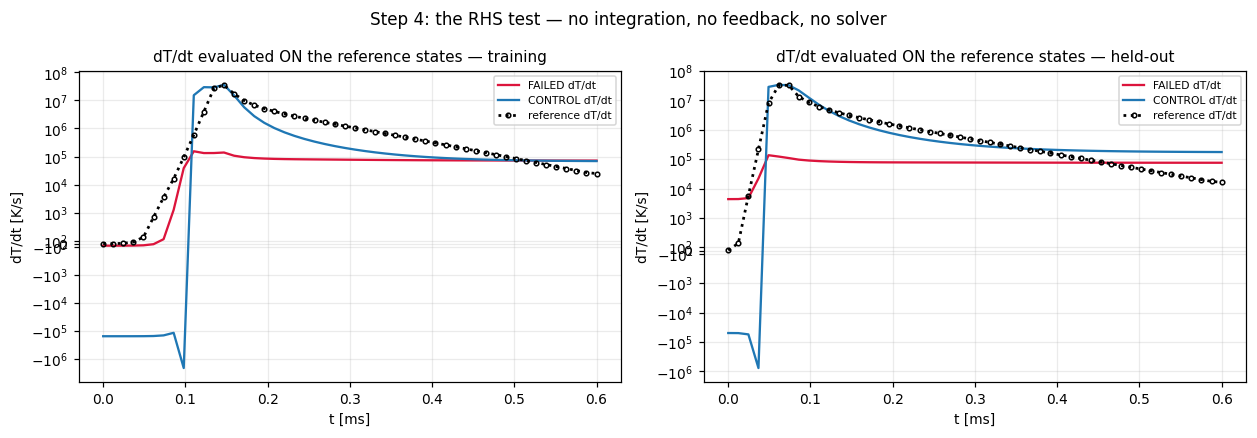

reference_peak_dTdt  model_dTdt_there   ratio  species_rate_relL2
condition model                                                                     
training  FAILED            3.5282e+07        1.3901e+05  0.0039              1.5202
          CONTROL           3.5282e+07        3.6008e+07  1.0206              0.7621
held-out  FAILED            3.2899e+07        1.0932e+05  0.0033              1.4727
          CONTROL           3.2899e+07        3.2965e+07  1.0020              0.5717

In [11]:
def rhs_along_reference(M, T0, phi):
    """Model d[Y,T]/dt evaluated ON the exact reference states (open loop, no integration)."""
    ref = reference(T0, phi)
    dyn = ChemKANDynamics(M["model"], input_normalizer=M["input_norm"])
    tf = torch.as_tensor(t, dtype=torch.float32)
    with torch.no_grad():
        model_rhs = torch.stack([
            dyn(tf[j], torch.as_tensor(ref[j], dtype=torch.float32).unsqueeze(0))[0]
            for j in range(len(t))]).numpy()
    return model_rhs, np.gradient(ref, t, axis=0), ref

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
rows = []
for ax, (T0, phi, role) in zip(axes, CONDS):
    for name, M, col in (("FAILED", FAILED, "crimson"), ("CONTROL", CONTROL, "#1f77b4")):
        mr, rr, ref = rhs_along_reference(M, T0, phi)
        kmax = int(rr[:, -1].argmax())                 # the reference heat-release peak
        ax.plot(t * 1e3, mr[:, -1], "-", lw=1.5, color=col, label=f"{name} dT/dt")
        rows.append(dict(condition=role, model=name,
                         reference_peak_dTdt=rr[kmax, -1], model_dTdt_there=mr[kmax, -1],
                         ratio=mr[kmax, -1] / rr[kmax, -1],
                         species_rate_relL2=float(np.linalg.norm(mr[:, :m] - rr[:, :m])
                                                  / np.linalg.norm(rr[:, :m]))))
    ax.plot(t * 1e3, rr[:, -1], "ko:", ms=3, mfc="none", lw=1.8, label="reference dT/dt")
    ax.set_yscale("symlog", linthresh=1e3)
    ax.set_title(f"dT/dt evaluated ON the reference states — {role}", fontsize=10)
    ax.set_xlabel("t [ms]"); ax.set_ylabel("dT/dt [K/s]"); ax.legend(fontsize=7)
fig.suptitle("Step 4: the RHS test — no integration, no feedback, no solver", fontsize=11)
fig.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index(["condition", "model"]))

**How to read it.**

* The **CONTROL** predicts a `dT/dt` of the right order at the ignition peak — `ratio` near 1.
* The **FAILED** model is short by more than two orders of magnitude, *at the exact correct state*.

That single comparison rules out a whole class of explanations. The failed model is not failing
because errors accumulated, or because it drifted into a bad region of state space, or
because the solver struggled. **Handed the truth, it still cannot produce heat release.**

Note also the `species_rate_relL2` column: the failed model's *species* rates have a relative L2
error of order one. So the kinetic core is not exact either — which is precisely why Step 3's
conclusion had to be "not inert" rather than "correct".

> **Common misinterpretation:** if you only ever integrate, you cannot separate "bad RHS" from "bad
> trajectory". Always evaluate the RHS on reference states before attributing the failure
> to training dynamics.

---
# Step 5 — Inside Eq. 15: is it the linear branch or the KAN correction?

Step 4 says the thermodynamic pathway is too weak. But that pathway has **two** parts:

$$\frac{dT}{dt} \;=\; \underbrace{\mathrm{Linear}\!\left(\frac{d\tilde u}{dt},\,\theta_{thermo}\right)}_{\text{Eq. 14 — nine scalars}} \;+\; \underbrace{\mathrm{KAN}_{cor}(u,\theta_{cor})}_{\text{Eq. 17 — the correction}}$$

Attributing the failure to "the thermo pathway" is not yet a diagnosis. Split it.

**The decisive variant:** push the **reference** species rates through the **learned**
`θ_thermo`. If even the *true* `dY/dt` cannot produce enough heat release through the learned
coefficients, then the coefficients themselves are wrong — the failure cannot be attributed to
the species rates the model produces.

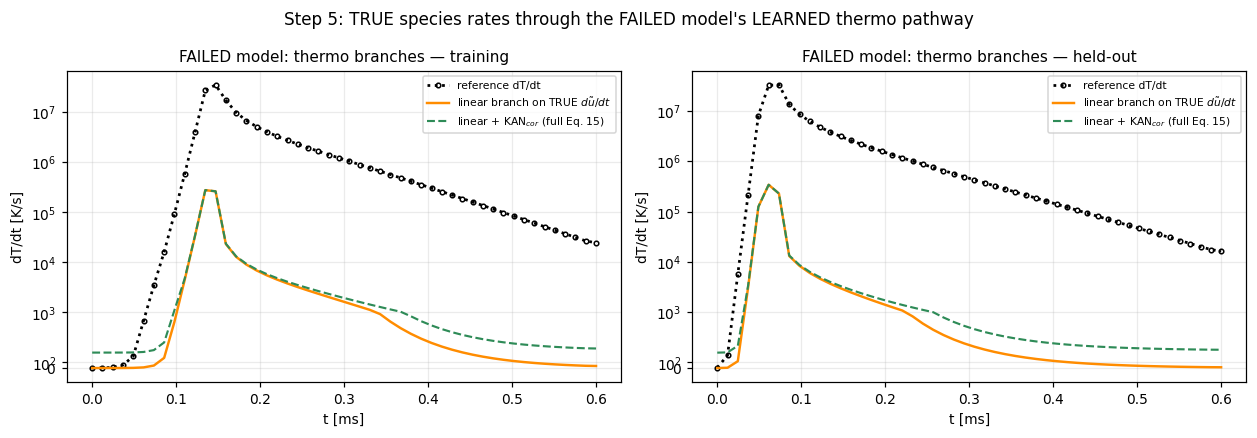

condition,training,held-out
reference,3.5282e+07,3.2899e+07
linear_branch,2.6330e+05,2.2727e+05
full_Eq15,2.6362e+05,2.2758e+05
correction,3.1540e+02,3.1698e+02
correction_share,1.1964e-03,1.3928e-03
deficit_linear,1.3400e+02,1.4476e+02
deficit_full,1.3384e+02,1.4456e+02


In [12]:
def thermo_branches(M, T0, phi):
    """Split Eq. 15 while feeding the branch the REFERENCE species rates."""
    ref = reference(T0, phi)
    dref = np.gradient(ref, t, axis=0)                       # sampled-trajectory derivative
    W = M["model"].thermo.linear.weight.detach().numpy().ravel()
    u = torch.as_tensor(ref, dtype=torch.float32)
    u_model = u if M["input_norm"] is None else M["input_norm"].normalize(u)
    with torch.no_grad():
        corr = M["model"].thermo.correction(u_model).numpy().ravel()
    lin = dref[:, :m] @ W                                     # linear branch on TRUE rates
    return dict(reference=dref[:, -1], linear=lin, correction=corr, full=lin + corr)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
rows = []
for ax, (T0, phi, role) in zip(axes, CONDS):
    b = thermo_branches(FAILED, T0, phi)
    kmax = int(b["reference"].argmax())
    ax.plot(t * 1e3, b["reference"], "ko:", ms=3, mfc="none", lw=1.8, label="reference dT/dt")
    ax.plot(t * 1e3, b["linear"], "-", color="darkorange", lw=1.6,
            label=r"linear branch on TRUE $d\tilde u/dt$")
    ax.plot(t * 1e3, b["full"], "--", color="seagreen", lw=1.4,
            label=r"linear + KAN$_{cor}$ (full Eq. 15)")
    ax.set_yscale("symlog", linthresh=1e3)
    ax.set_title(f"FAILED model: thermo branches — {role}", fontsize=10)
    ax.set_xlabel("t [ms]"); ax.set_ylabel("dT/dt [K/s]"); ax.legend(fontsize=7)
    rows.append(dict(condition=role,
                     reference=b["reference"][kmax], linear_branch=b["linear"][kmax],
                     full_Eq15=b["full"][kmax], correction=b["correction"][kmax],
                     correction_share=abs(b["correction"][kmax]) / (abs(b["full"][kmax]) + 1e-30),
                     deficit_linear=b["reference"][kmax] / b["linear"][kmax],
                     deficit_full=b["reference"][kmax] / b["full"][kmax]))
fig.suptitle("Step 5: TRUE species rates through the FAILED model's LEARNED thermo pathway",
             fontsize=11)
fig.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index("condition").T)

**How to read it.** Two numbers decide this:

* `deficit_linear` vs `deficit_full` — if they are nearly equal, the KAN correction is not
  meaningfully changing the answer.
* `correction_share` — how much of the total the correction actually contributes at the
  heat-release peak.

Here the correction contributes a fraction of a percent, and the two deficits are
indistinguishable. **The failure is in the Eq. 14 linear branch.** `KAN_cor` neither causes it
nor masks it.

That is a *localized* diagnosis: nine scalars.

---
# Step 6 — "Scaling" is four different questions. Never conflate them.

When a scaling problem is suspected — a natural hypothesis, since mass fractions are O(0.01–1)
while temperature is O(10³) K — it is essential to specify **which** scaling. Four distinct
ones exist in this codebase, and conflating them leads to unproductive work:

| # | Scaling | Where | Paper status |
|---|---|---|---|
| 1 | **Loss normalization** — each state min-max'd to [0,1] before the MSE | Eq. 18 | **PAPER-EXPLICIT** |
| 2 | **Network input scaling** — the state copy handed to the KAN is min-max'd | `dynamics.py` | repo choice, *not* paper-stated |
| 3 | **ODE state coordinates** — what the solver actually integrates | `solver` | physical (verify in code!) |
| 4 | **Scale of `θ_thermo`** multiplying *physical* `dY/dt` | Eq. 14 | not documented anywhere |

Only #4 turned out to be the striking one. But you cannot know that until you separate them.

**Verify #3 from the code, never from memory** — the required coefficient magnitude depends
entirely on it.

In [13]:
import inspect
print(inspect.getsource(ChemKANDynamics.forward))
print(inspect.getsource(type(FAILED["model"].thermo).forward))
print("Reading the code: the solver integrates PHYSICAL [Y,T]; the normalizer touches only")
print("the COPY handed to the KAN; the returned derivative is PHYSICAL and is never")
print("de-normalized. => thermo.linear multiplies PHYSICAL dY/dt and must carry the FULL")
print("heat-release scale.\n")

R_Y = (npz["u_max"] - npz["u_min"])[:m]
R_T = float((npz["u_max"] - npz["u_min"])[-1])
Y0 = resolve_training_ic(npz["train_ics"], npz["train_states"], 1050.0, 0.5, species_dim=m)
c_phys, cp = cantera_coefficients(1050.0, Y0, species=species, mech=MECH)
w_learned = FAILED["model"].thermo.linear.weight.detach().numpy().ravel()

scale = pd.DataFrame({
    "learned θ_thermo (FAILED)": w_learned,
    "physical  −h_k/cp  [K]": c_phys,
    "if states were normalized: c·R_Y/R_T": c_phys * R_Y / R_T,
}, index=species)
display(scale.round(3))
print(f"‖learned‖ = {np.linalg.norm(w_learned):9.3f}")
print(f"‖physical‖ = {np.linalg.norm(c_phys):9.3f}   -> ratio "
      f"{np.linalg.norm(c_phys)/np.linalg.norm(w_learned):.0f}x")
print(f"‖normalized-coordinate equivalent‖ = {np.linalg.norm(c_phys*R_Y/R_T):.3f}")
print(f"default nn.Linear init bound = ±1/√{m} = ±{1/np.sqrt(m):.3f}")

    def forward(self, t: torch.Tensor, u_physical: torch.Tensor) -> torch.Tensor:
        # (B, m+1) physical -> (B, m+1) physical derivative
        u_model = (u_physical if self.input_normalizer is None
                   else self.input_normalizer.normalize(u_physical))
        return self.model(u_model)

    def forward(self, u: torch.Tensor, dYdt: torch.Tensor) -> torch.Tensor:
        # u: (B, m+1), dYdt: (B, m) -> dT/dt: (B, 1)
        return self.linear(dYdt) + self.correction(u)

Reading the code: the solver integrates PHYSICAL [Y,T]; the normalizer touches only
the COPY handed to the KAN; the returned derivative is PHYSICAL and is never
de-normalized. => thermo.linear multiplies PHYSICAL dY/dt and must carry the FULL
heat-release scale.



,learned θ_thermo (FAILED),physical −h_k/cp [K],if states were normalized: c·R_Y/R_T
H2,-18.278,-8093.169,-0.186
H,15.226,-170340.893,-0.648
O,16.786,-12176.997,-0.126
O2,-18.772,-561.727,-0.070
OH,19.462,-2670.947,-0.031
H2O,18.333,8719.918,1.142
HO2,3.517,-990.885,-0.000
H2O2,2.497,2050.042,0.000
N2,-0.540,-606.410,-0.007


‖learned‖ =    43.975
‖physical‖ = 171227.443   -> ratio 3894x
‖normalized-coordinate equivalent‖ = 1.334
default nn.Linear init bound = ±1/√9 = ±0.333


**How to read it.** In *physical* coordinates (what this code integrates) the coefficients
must be O(10³–10⁵). In *normalized* coordinates the same physics needs coefficients of order
1 — which is exactly where PyTorch's default `nn.Linear` initialization puts them. So the
default initialization is well-scaled for a representation this repo does **not** use.

> **Two common misinterpretations:**
>
> 1. **Do not "just remove the min-max input scaling and see what happens."** Raw `T` of
>    1000–3000 K entering a `tanh`-normalized KAN saturates instantly (`tanh(1000) = 1`).
>    Removing #2 does not test #4; it breaks the network in a different way. Audit each
>    scaling separately.
> 2. **Do not conclude the paper's authors used normalized derivatives.** The paper writes
>    Eq. 14 in physical variables and is silent on implementation. What you can say is what
>    *your* code does — which you just read off the source.

---
# Step 7 — How do the Eq. 14 coefficients evolve during training?

Step 5 localized the failure to nine scalars. The most direct way to understand what happened
to them is to **plot them**: `stage2_probe.csv` records all nine coefficients at every probe
epoch, so their entire trajectory through training is available without re-running anything.

Start with the plot. Quantify afterwards, only to explain what the plot shows.

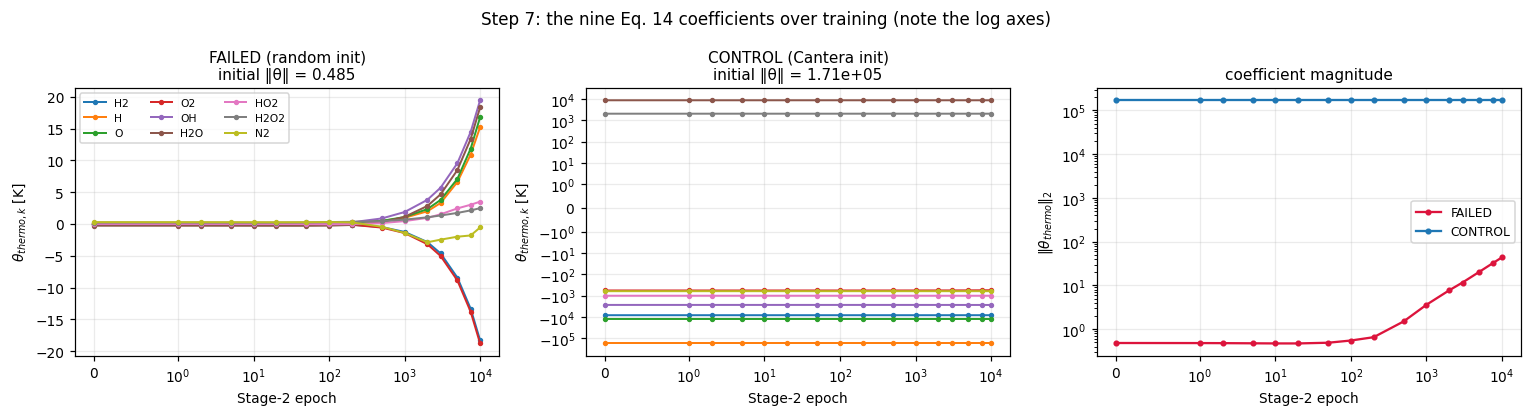

In [14]:
COEFF = [f"coeff_{s}" for s in species]

def theta_history(M):
    pr = pd.read_csv(M["run_dir"] / "stage2_probe.csv")
    return pr["epoch"].to_numpy(int), pr[COEFF].to_numpy(float)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
cmap = plt.get_cmap("tab10")
for ax, (name, M) in zip(axes[:2], (("FAILED (random init)", FAILED),
                                    ("CONTROL (Cantera init)", CONTROL))):
    ep, th = theta_history(M)
    for k, sp in enumerate(species):
        ax.plot(ep, th[:, k], "-o", ms=2.5, lw=1.3, color=cmap(k % 10), label=sp)
    ax.set_xscale("symlog", linthresh=1)
    if np.abs(th).max() > 1e3:
        ax.set_yscale("symlog", linthresh=1.0)
    ax.set_title(f"{name}\ninitial ‖θ‖ = {np.linalg.norm(th[0]):.3g}", fontsize=10)
    ax.set_xlabel("Stage-2 epoch"); ax.set_ylabel(r"$\theta_{thermo,k}$ [K]")
axes[0].legend(fontsize=7, ncol=3)

for name, M, c in (("FAILED", FAILED, "crimson"), ("CONTROL", CONTROL, "#1f77b4")):
    ep, th = theta_history(M)
    axes[2].plot(ep, np.linalg.norm(th, axis=1), "-o", ms=3, color=c, label=name)
axes[2].set_xscale("symlog", linthresh=1); axes[2].set_yscale("log")
axes[2].set_xlabel("Stage-2 epoch"); axes[2].set_ylabel(r"$\|\theta_{thermo}\|_2$")
axes[2].set_title("coefficient magnitude", fontsize=10); axes[2].legend(fontsize=8)
fig.suptitle("Step 7: the nine Eq. 14 coefficients over training (note the log axes)",
             fontsize=11)
fig.tight_layout(); plt.show()

**How to read it.** The two panels show qualitatively different behaviour:

* **FAILED** — the coefficients start near zero, move substantially in relative terms, and
  end at O(10). The signs rearrange completely. Yet the final magnitude is still orders below
  the physical scale established in Step 6, so all that movement did not reach the required
  regime.
* **CONTROL** — the coefficients start at the physical scale and are visually *flat*. Nothing
  appears to happen to them across 10 000 epochs.

The natural reading of the CONTROL panel — "the optimizer never touched these" — is
**incorrect**, and the next two cells show why. This is where a plot alone can mislead, and
where quantification is genuinely required.

Two quantities are needed, and they answer different questions:

1. **The gradient** `∂L/∂θ` — is there any signal driving these parameters at all?
   Measured with one forward + one backward pass on the exact training objective; no
   optimizer step is taken and no parameter is modified.
2. **The optimizer's step budget** — how far *can* Adam move them, irrespective of gradient
   magnitude? Adam normalizes by the gradient's running RMS, so its per-coordinate step is
   bounded by approximately `lr`, whatever the gradient is.

In [15]:
d2 = load_hydrogen(split="train")
fn2 = MinMaxNormalizer(d2["u_min"], d2["u_max"])
tgt = fn2.normalize(d2["full_TBm1"])

def block_gradients(M):
    """One forward+backward on the real Stage-2 loss. Takes NO optimizer step."""
    ck = torch.load(M["run_dir"] / "checkpoint_final.pt", map_location="cpu",
                    weights_only=False)
    mdl = build_chemkan(ck, m, "cpu"); mdl.train()
    for p in mdl.parameters():
        p.requires_grad_(True)
    dyn = ChemKANDynamics(mdl, input_normalizer=load_input_scaling(ck, "cpu"))
    pred = integrate(dyn, d2["full_TBm1"][0], d2["t"], solver_from_ckpt(ck))
    loss = chemkan_loss(fn2.normalize(pred), tgt, use_pinn=True, alpha_pinn=1e-4,
                        Y_phys=pred[..., :m], element_counts=ELEMENT_COUNTS,
                        atomic_weights=ATOMIC_WEIGHTS, molar_weights=MOLAR_WEIGHTS)
    mdl.zero_grad(set_to_none=True); loss.backward()
    g = {n: p.grad.detach() for n, p in mdl.named_parameters() if p.grad is not None}
    nrm = lambda pre: float(torch.linalg.vector_norm(
        torch.cat([v.reshape(-1) for k, v in g.items() if k.startswith(pre)])))
    return dict(loss=float(loss.detach()), kinetic=nrm("kinetic"),
                thermo_linear=nrm("thermo.linear"), thermo_correction=nrm("thermo.correction"))

grad = pd.DataFrame({n: block_gradients(M)
                     for n, M in (("FAILED", FAILED), ("CONTROL", CONTROL))}).T
grad["thermo_linear / kinetic"] = grad.thermo_linear / grad.kinetic
display(grad)
print("The nine Eq.14 scalars receive a gradient ~5-6 ORDERS OF MAGNITUDE smaller than the")
print("kinetic core's. They are the most weakly driven parameters in the network.")

,loss,kinetic,thermo_linear,thermo_correction,thermo_linear / kinetic
FAILED,2.1228,48.4900,7.8526e-04,9.6506e-06,1.6194e-05
CONTROL,0.2369,19.0782,1.8802e-05,2.8691e-06,9.8553e-07


The nine Eq.14 scalars receive a gradient ~5-6 ORDERS OF MAGNITUDE smaller than the
kinetic core's. They are the most weakly driven parameters in the network.


In [16]:
# ...but a tiny gradient does NOT by itself explain small movement, because Adam normalizes.
# Adam's per-coordinate step is bounded by ~lr regardless of gradient magnitude, so over N
# steps a p-dimensional vector can travel at most about lr * N * sqrt(p).
LR, N_STEPS = 2e-3, 10000
ceiling = LR * N_STEPS * np.sqrt(m)
print(f"Adam displacement ceiling ≈ lr·steps·√{m} = {ceiling:.1f}\n")

rows = []
for name, M in (("FAILED", FAILED), ("CONTROL", CONTROL)):
    pr = pd.read_csv(M["run_dir"] / "stage2_probe.csv")
    cols = [f"coeff_{s}" for s in species]
    th0, thf = pr[cols].to_numpy(float)[0], pr[cols].to_numpy(float)[-1]
    disp = float(np.linalg.norm(thf - th0))
    rows.append(dict(model=name, init_norm=np.linalg.norm(th0), final_norm=np.linalg.norm(thf),
                     abs_displacement=disp, pct_of_Adam_ceiling=100 * disp / ceiling,
                     relative_displacement=disp / np.linalg.norm(th0),
                     cos_final_init=float(thf @ th0 / (np.linalg.norm(thf) * np.linalg.norm(th0)))))
display(pd.DataFrame(rows).set_index("model"))

Adam displacement ceiling ≈ lr·steps·√9 = 60.0



,init_norm,final_norm,abs_displacement,pct_of_Adam_ceiling,relative_displacement,cos_final_init
model,,,,,,
FAILED,0.4848,43.9749,44.0125,73.3541,90.7798,-0.0719
CONTROL,171227.5497,171227.1274,26.9999,44.9998,0.0002,1.0000


**How to read it.**

The CONTROL's `relative_displacement` is ~1e-4, which *looks* like "the optimizer never
touched it". That reading is **wrong**. Look at `pct_of_Adam_ceiling`: it moved ~45 % of the
maximum distance Adam permits in 10 000 steps. It is moving nearly as fast as it can — it
simply cannot travel far *relative to* a vector of norm 1.7e5.

So the correct statement is mechanical, not motivational:

> A `θ_thermo` initialized at O(10⁵) **cannot be rotated appreciably** within this budget, so
> whatever sign structure it starts with is effectively **locked in** for the whole run.
> Meanwhile the FAILED model, starting at O(0.1), rotates completely (`cos_final_init` far from 1)
> and still ends ~4 orders too small.

> **Common misinterpretation:** `relative_displacement` largely measures `1/‖θ₀‖`. Never read it as evidence
> about gradients without checking the absolute displacement against the optimizer's ceiling.

---
# Step 8 — Two common sources of misinterpretation

### 8a. A smooth, decreasing loss does not mean correct dynamics

The FAILED model's Stage-2 loss falls smoothly by an order of magnitude while the temperature
never moves. Smooth convergence to a *wrong* basin looks exactly like healthy training on a
loss curve.

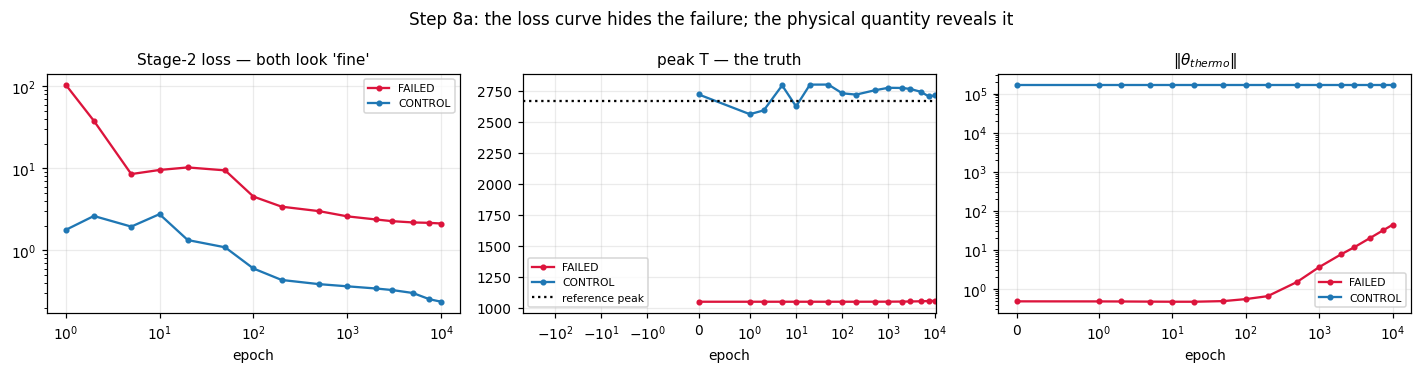

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for name, M, col in (("FAILED", FAILED, "crimson"), ("CONTROL", CONTROL, "#1f77b4")):
    pr = pd.read_csv(M["run_dir"] / "stage2_probe.csv")
    pr["ignites"] = pr["ignites"].astype(str).str.lower().eq("true")
    axes[0].plot(pr.epoch, pr.stage2_loss, "o-", ms=3, color=col, label=name)
    axes[1].plot(pr.epoch, pr.peak_T_K, "o-", ms=3, color=col, label=name)
    axes[2].plot(pr.epoch, pr.thermo_linear_norm, "o-", ms=3, color=col, label=name)
axes[1].axhline(reference(1050., .9)[:, -1].max(), color="k", ls=":", label="reference peak")
for ax, ttl, log in ((axes[0], "Stage-2 loss — both look 'fine'", True),
                     (axes[1], "peak T — the truth", False),
                     (axes[2], r"$\|\theta_{thermo}\|$", True)):
    ax.set_title(ttl, fontsize=10); ax.set_xscale("symlog", linthresh=1); ax.set_xlabel("epoch")
    if log: ax.set_yscale("log")
    ax.legend(fontsize=7)
fig.suptitle("Step 8a: the loss curve hides the failure; the physical quantity reveals it",
             fontsize=11)
fig.tight_layout(); plt.show()

### 8b. A single scalar will rank your models wrongly

Peak temperature alone, ignition delay alone, and final loss alone each rank at least one
model incorrectly. **Always look at the trajectory shape**, and quote a metric with its
convention.

Two conventions require particular care:

* **Eq. 18 SUMS over the observation times**; a per-state *mean* differs by a factor `Nt`
  (here 50). A number quoted without its convention is not comparable to the paper.
* **Ignition delay is grid-dependent.** `argmax dT/dt` on a 50-point grid is quantized to
  ~12 µs. Compare model and reference **within the same grid**, and use a *genuine* dense
  Cantera reference — never `np.interp` of the 50-point data dressed up as "dense".

In [18]:
rows = []
for name, M in (("FAILED", FAILED), ("CONTROL", CONTROL)):
    for T0, phi, role in CONDS:
        Td = closed_loop(M, T0, phi, T_DENSE)[:, -1]
        r50 = reference(T0, phi)[:, -1]
        rdn = reference_T_dense(T0, phi)
        d50 = ignition_delay(t, closed_loop(M, T0, phi)[:, -1])
        ddn = ignition_delay(T_DENSE, Td)
        rows.append(dict(model=name, condition=role,
                         peak_T=Td.max(), ref_peak_T=rdn.max(), peak_err=Td.max() - rdn.max(),
                         delay_50_ms=np.nan if d50 is None else d50 * 1e3,
                         ref_50_ms=ignition_delay(t, r50) * 1e3,
                         delay_dense_ms=np.nan if ddn is None else ddn * 1e3,
                         ref_dense_ms=ignition_delay(T_DENSE, rdn) * 1e3))
display(pd.DataFrame(rows).set_index(["model", "condition"]).round(4))
print("Note how the REFERENCE delay itself shifts between the 50-point and dense grids.")
print("That is exactly why model_dense must never be compared against reference_50.")

peak_T  ref_peak_T   peak_err  delay_50_ms  ref_50_ms  delay_dense_ms  ref_dense_ms
model   condition                                                                                        
FAILED  training   1058.0077   2669.7177 -1611.7100          NaN     0.1469             NaN        0.1419
        held-out   1159.5980   2761.5843 -1601.9863          NaN     0.0735             NaN        0.0631
CONTROL training   2714.0945   2669.7177    44.3767       0.1469     0.1469          0.1382        0.1419
        held-out   3029.1331   2761.5843   267.5487       0.0612     0.0735          0.0516        0.0631

Note how the REFERENCE delay itself shifts between the 50-point and dense grids.
That is exactly why model_dense must never be compared against reference_50.


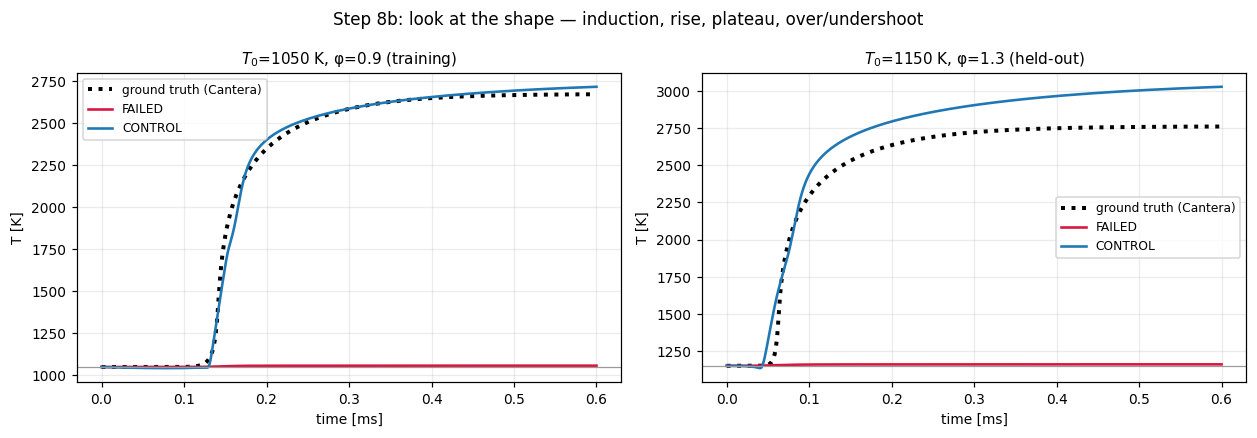

In [19]:
# The trajectory shape -- what every scalar above fails to convey.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for ax, (T0, phi, role) in zip(axes, CONDS):
    ax.plot(T_DENSE * 1e3, reference_T_dense(T0, phi), "k:", lw=2.6, label="ground truth (Cantera)")
    for name, M, col in (("FAILED", FAILED, "crimson"), ("CONTROL", CONTROL, "#1f77b4")):
        ax.plot(T_DENSE * 1e3, closed_loop(M, T0, phi, T_DENSE)[:, -1], "-", lw=1.7,
                color=col, label=name)
    ax.axhline(T0, color="#999", lw=.8)
    ax.set_title(f"$T_0$={T0:.0f} K, φ={phi} ({role})", fontsize=10)
    ax.set_xlabel("time [ms]"); ax.set_ylabel("T [K]"); ax.legend(fontsize=8)
fig.suptitle("Step 8b: look at the shape — induction, rise, plateau, over/undershoot",
             fontsize=11)
fig.tight_layout(); plt.show()

---
# The checklist

Print this. Work down it. Stop when a step localizes the fault.

```
0  DATA        Is this condition supposed to ignite at all?
               → reference rise > 100 K?  If not, a flat prediction is CORRECT.

1  ATTRIBUTION Which state carries the closed-loop error, in Eq.18 coordinates?
               → normalize first; in raw units temperature always dominates.

2  COUPLING    Do species evolve while T stays wrong?
               → if yes, the coupling is suspect -- but verify against an ISOTHERMAL
                 reference at that fixed T before calling the kinetics broken
                 (real H2 chemistry DOES react fully at a frozen 1050 K).
               → plot radicals (H,O,OH,HO2,H2O2) on a LOG axis, not just H2/O2/H2O.

3  OPEN LOOP   Feed the TRUE T(t); does the kinetic core produce sensible species?
               → also verify the temperature provider/interpolation itself.
               → a pass means "not inert", NOT "correct".

4  RHS TEST    At the exact reference states (incl. the ignition region), what dT/dt
               does the model predict vs the truth?          ← the key diagnostic
               → removes integration, feedback and solver from the question.
               → reference dY/dt from np.gradient is APPROXIMATE, and generous.

5  SPLIT Eq.15 Linear branch vs KAN_cor, using the REFERENCE dY/dt.
               → if the deficit survives with true rates, the COEFFICIENTS are wrong.

6  SCALING     WHICH scaling? loss-norm / input-scaling / ODE coordinates / θ_thermo.
               → read the forward path in the code; never assume.
               → do NOT "just remove the input scaling to see".

7  OPTIMIZER   Gradient per block (one backward pass) AND displacement vs the Adam
               ceiling (lr·steps·√p).
               → relative displacement mostly measures 1/‖θ₀‖. Don't over-read it.

8  INTERPRETATION
               → a smooth loss curve says nothing about dynamics;
               → no single scalar ranks models correctly; look at T(t) shape;
               → quote metric conventions (Eq.18 sums over time; delays are grid-dependent).
```

---
# Hypotheses to be careful with

Not every plausible-sounding fix deserves a day of work. Two that came up and should **not**
be leading hypotheses here:

**"Maybe it should integrate enthalpy instead of temperature."**
A reasonable combustion-troubleshooting instinct, but the paper explicitly defines the state
as `u = [Y₁…Y_m, T]` and its thermodynamic superstructure outputs `dT/dt`, not an enthalpy
state. Redesigning the reproduction around an enthalpy-integrated ODE would be *deviating
from the paper* to fix a bug we have already localized elsewhere. Don't, unless a concrete
paper/code source supports it.

**"Maybe the input min-max scaling is the problem — remove it and see."**
Removing it does not test the coefficient-scale hypothesis; it breaks the network a different
way, because raw `T ≈ 1000–3000 K` saturates the KAN's internal `tanh` immediately. Audit the
four scalings separately (Step 6) rather than deleting one at random.

**And one piece of methodological hygiene:** if a stated architecture does not reproduce a
published parameter count, **report the inconsistency** — don't quietly distort the
architecture until the number matches. If two different configurations both reproduce the
count, say so and treat each as an explicitly-labelled *inferred interpretation*.

---
# What a good conclusion sounds like

Compare these two write-ups of the same investigation:

| ❌ overclaimed | ✅ defensible |
|---|---|
| "The species work, the temperature is broken." | "Temperature dominates the closed-loop error, and the thermodynamic pathway is independently severely inadequate. The kinetic pathway is active but has **not** been established as quantitatively correct." |
| "The thermo network is broken." | "The deficit survives when the *true* species rates are pushed through the learned coefficients, and `KAN_cor` contributes <1 % at the heat-release peak — so it is the **Eq. 14 linear branch**." |
| "The coefficients are too small, so training just needs longer." | "The coefficients are ~4 orders too small in *physical* coordinates. Their gradient is 5–6 orders below the kinetic core's, and the arms move at 45–82 % of the Adam step ceiling — so 'train longer' is not supported." |
| "Scaling is wrong." | "Of the four distinct scalings, #1 and #2 were audited and are not implicated; the striking one is #4, the scale of `θ_thermo` multiplying *physical* `dY/dt` — a quantity the paper does not document." |

The right-hand column is not more cautious for its own sake. Each statement names **which
diagnostic** supports it, which is what makes it survive a supervisor's follow-up question.

---

### Categories to keep separate in every write-up

| tag | meaning |
|---|---|
| **PAPER-EXPLICIT** | stated in the paper, with a locatable equation/section |
| **INFERRED** | not stated; chosen to make the paper's own description self-consistent |
| **IMPLEMENTATION CHOICE** | a decision this repo made that the paper does not constrain |
| **DIAGNOSTIC / ABLATION** | an experiment to understand a failure — never a reproduction result |

Blurring these is the fastest way to turn a good investigation into an indefensible claim.

In [20]:
print("Diagnostic playbook executed end to end. Nothing was trained; no checkpoint modified.")
print("\nFor the full recorded investigation of THIS failure, see")
print("  chemkan/notebooks/09_hydrogen_thermo_failure_analysis.ipynb")
print("This notebook is the METHOD; notebook 09 is the RESULT.")

Diagnostic playbook executed end to end. Nothing was trained; no checkpoint modified.

For the full recorded investigation of THIS failure, see
  chemkan/notebooks/09_hydrogen_thermo_failure_analysis.ipynb
This notebook is the METHOD; notebook 09 is the RESULT.
